In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, Slider
from matplotlib import cm, colors
import scipy as sp
from sympy import *
%matplotlib widget
plt.ion()


In [ ]:
delta = 8/9

def A(x):
	return np.sqrt(1-delta**2*(1/np.cosh(x))**2)

r_minus_max = -A(0)
r_plus_min = A(0)

r_minus_max, r_plus_min

In [ ]:
def integrand(eta,endpts,p, branch:str):
	alpha = endpts[0]
	beta = endpts[1]
	if branch=='neg':
		# return eta**p*np.sqrt(eta-alpha)/np.sqrt(-(1-eta**2)*(eta-beta))*(p+1 + (eta*(3*eta**2-2*beta*eta-1)/(2*(1-eta**2)*(eta-beta))))
		# return np.sqrt(eta-alpha)*( ((p+1)*eta**p)/np.sqrt(-(1-eta**2)*(eta - beta)) - eta**(p+1)*(3*eta**2-2*beta*eta-1)/(2*((1-eta**2)*(beta-eta))**(3/2) ))
		return (p+1)*eta**p*np.sqrt((eta-alpha)/((1-eta**2)*(beta-eta))) - (1/2)*eta**(p+1)*((3*eta**2-2*beta*eta-1)/((1-eta**2)*(beta-eta)))*np.sqrt((eta-alpha)/((1-eta**2)*(beta-eta)))
	
	if branch=='pos':
		# return eta**p*np.sqrt(beta-eta)/np.sqrt((1-eta**2)*(eta-alpha))*(p+1 + (eta*(3*eta**2-2*alpha*eta-1)/(2*(1-eta**2)*(eta-alpha))))
		# return np.sqrt(beta - eta)*( ((p+1)*eta**p)/np.sqrt((1-eta**2)*(eta - alpha)) -  eta**(p+1)*(-3*eta**2+2*alpha*eta+1)/(2*((1-eta**2)*(eta-alpha))**(3/2)))
		return (p+1)*eta**p*np.sqrt((beta-eta)/((1-eta**2)*(eta-alpha))) - (1/2)*eta**(p+1)*((-3*eta**2+2*alpha*eta+1)/((1-eta**2)*(eta-alpha)))*np.sqrt((beta-eta)/((1-eta**2)*(eta-alpha)))
	else: 
		return ValueError('Need to specify branch.')


def total_moments(endpts:list,p,x,t, error=False):
	alpha = endpts[0]
	beta = endpts[1]
	
	# minus_moment = r_minus_max**(p+1)*np.sqrt(r_minus_max - alpha)/np.sqrt(-(1-r_minus_max**2)*(r_minus_max-beta)) - sp.integrate.quad(integrand, alpha,r_minus_max, args=(endpts,p,'neg'),points=alpha)[0]
	# plus_moment = -r_plus_min**(p+1)*np.sqrt(beta-r_plus_min)/np.sqrt((1-r_plus_min**2)*(r_plus_min-alpha)) - sp.integrate.quad(integrand, r_plus_min,beta, args=(endpts,p,'pos'), points=beta)[0]
	minus_moment = r_minus_max**(p+1)*np.sqrt(r_minus_max - alpha)/np.sqrt((1-r_minus_max**2)*(beta-r_minus_max)) - sp.integrate.quad(integrand, alpha,r_minus_max, args=(endpts,p,'neg'),points=alpha)[0]
	plus_moment = -r_plus_min**(p+1)*np.sqrt(beta-r_plus_min)/np.sqrt((1-r_plus_min**2)*(r_plus_min-alpha)) - sp.integrate.quad(integrand, r_plus_min,beta, args=(endpts,p,'pos'), points=beta)[0]
	sum_of_moments = minus_moment + plus_moment

	if p==0:
		result = sum_of_moments + x+ (alpha+beta)*t
	
	if p==1:
		result = sum_of_moments + (1/2)*( (alpha+beta)*x + ( (3/2)*alpha**2 + (3/2)*beta**2 + alpha*beta )*t)

	# if error==True:
	# 	print(f"The error from numerically integrating the p={p} moment is {sum_of_moments[1]}.")
	
	return result
	# return np.array([np.real(result),np.imag(result).imag])



def total_moments_system(endpts,x,t, error=False):
	matrix = np.array([total_moments(endpts,0,x,t), total_moments(endpts,1,x,t)])
	return matrix



In [ ]:
# testing for t=0 at
x0 = 10
t0= 0
alpha = -A(x0)
beta = A(x0)
endpts = [alpha,beta]

endpts, sp.optimize.fsolve(total_moments_system, [-A(x0),A(x0)], args=(x0,t0))


In [ ]:
x_window = 5
t_window = 2
num_xsamples = 20
num_tsamples = 10
X = np.linspace(0, x_window, num_xsamples)
T = np.linspace(0, t_window, num_tsamples)

In [ ]:
for i in range(len(X)):
	x0 = X[i]
	result = [total_moments([-A(x0),A(x0)],0,x0,0),total_moments([-A(x0),A(x0)],1,x0,0)]
	print(result)

In [ ]:
alphas = np.zeros_like(X)
betas = np.zeros_like(X) 

In [ ]:
init_alphas = np.zeros_like(X)
init_betas = np.zeros_like(X)


In [ ]:
for i in range(len(X)):
	x0 = X[i]
	roots = sp.optimize.fsolve(total_moments_system, [-A(x0),A(x0)], args=(x0,0))
	init_alphas[i] = roots[0]
	init_betas[i] = roots[1]

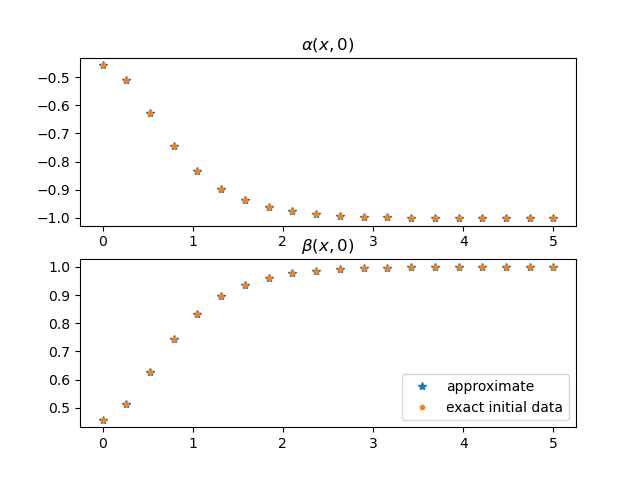

In [79]:

plt.close()
fig, axs = plt.subplots(2)
axs[0].plot(X,init_alphas, label="approximate",marker='*',linestyle='none')
axs[0].plot(X, -A(X), label="exact initial data",marker='.',linestyle='none')
axs[0].set_title(r'$\alpha(x,0)$')
axs[1].plot(X,init_betas, label="approximate",marker='*',linestyle='none')
axs[1].plot(X, A(X), label="exact initial data",marker='.',linestyle='none')
axs[1].set_title(r'$\beta(x,0)$')
plt.legend()
# plt.show()

In [ ]:
XX, TT = np.meshgrid(X,T)


In [ ]:
alphas = np.zeros_like(XX)
betas = np.zeros_like(XX)
alphas[0]=-A(X)
betas[0]=A(X)
alphas[0]

In [ ]:
# new_alphas = np.zeros(num_xsamples)
# new_betas = np.zeros(num_xsamples)
# # next time, t0=T[1]
# t_idx = 1
# for x_idx in range(num_xsamples):
# 	result = sp.optimize.fsolve(total_moments_system, [alphas[t_idx-1][x_idx],betas[t_idx-1][x_idx]], args=(X[x_idx],T[t_idx]))
# 	new_alphas[x_idx] = result[0]
# 	new_betas[x_idx] = result[1]

In [ ]:
# new_alphas

In [ ]:
# new_betas

In [ ]:
alphas[0]
T[1]

In [ ]:
for t_idx in range(1,num_tsamples):
	for x_idx in range(num_xsamples):
		result = sp.optimize.fsolve(total_moments_system, [alphas[t_idx-1][x_idx],betas[t_idx-1][x_idx]], args=(X[x_idx],T[t_idx]))
		alphas[t_idx][x_idx] = result[0]
		betas[t_idx][x_idx] = result[1]

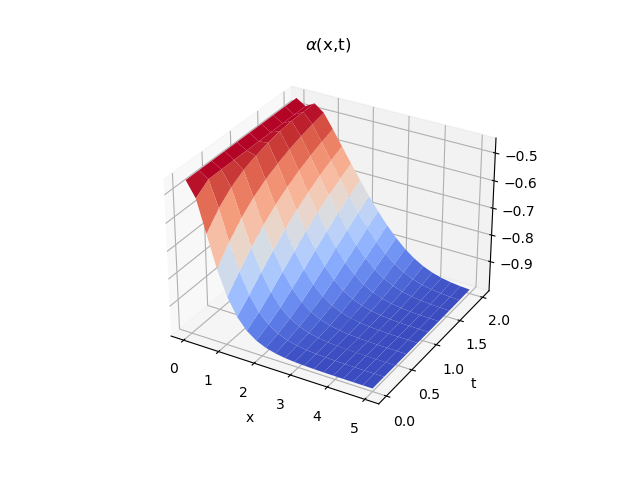

In [86]:
plt.close()
fig2, ax2 = plt.subplots(subplot_kw={"projection": "3d"}, num=' ')
ax2.clear()
ax2.plot_surface(XX,TT, alphas, cmap="coolwarm")
ax2.set_title(r"$\alpha$(x,t)")
ax2.set_xlabel('x')
ax2.set_ylabel('t')
plt.show()

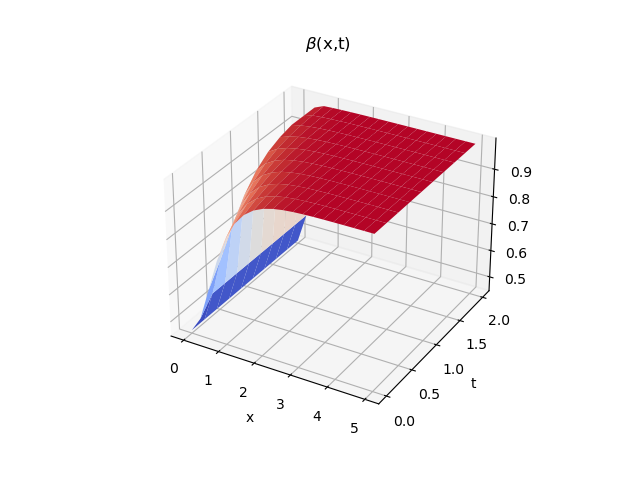

In [87]:
plt.close()
fig3, ax3 = plt.subplots(subplot_kw={"projection": "3d"}, num=' ')
ax3.clear()
ax3.plot_surface(XX,TT, betas, cmap='coolwarm')
ax3.set_title(r"$\beta$(x,t)")
ax3.set_xlabel('x')
ax3.set_ylabel('t')
plt.show()

In [88]:
alphas[:][1]

array([-0.45812285, -0.47955148, -0.5719678 , -0.6820474 , -0.77930094,
       -0.85429081, -0.90731013, -0.94257468, -0.9650514 , -0.97897413,
       -0.98744115, -0.99253154, -0.99557048, -0.99737704, -0.99844828,
       -0.99908253, -0.99945772, -0.99967954, -0.99981065, -0.99988812])

0

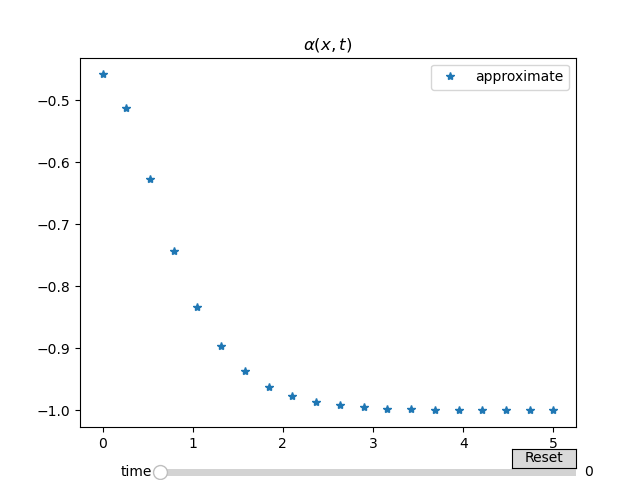

In [112]:
# graph of alpha(x) for fixed values of t
plt.close()
fig, axs = plt.subplots(num=' ')
p, = axs.plot(X,alphas[0], label="approximate",marker='*',linestyle='none')
axs.set_title(r'$\alpha(x,t)$')
plt.legend()

ax_time = fig.add_axes((0.25, 0.001, 0.65, 0.03))

time_slider = Slider(
    ax=ax_time,
    label="time",
    valinit=0,
    valmin =0,
    valmax=num_tsamples,
    valstep=range(num_tsamples),
    orientation="horizontal"
)


# The function to be called anytime a slider's value changes
def update(val):
    p.set_ydata(alphas[:][time_slider.val])
    fig.canvas.draw_idle()


# register the update function with each slider
time_slider.on_changed(update)

# Create a `matplotlib.widgets.Button` to reset the sliders to initial values.
time_reset = fig.add_axes((0.8, 0.025, 0.1, 0.04))
button = Button(time_reset, 'Reset', hovercolor='0.975')


def reset(event):
    time_slider.reset()
button.on_clicked(reset)

0

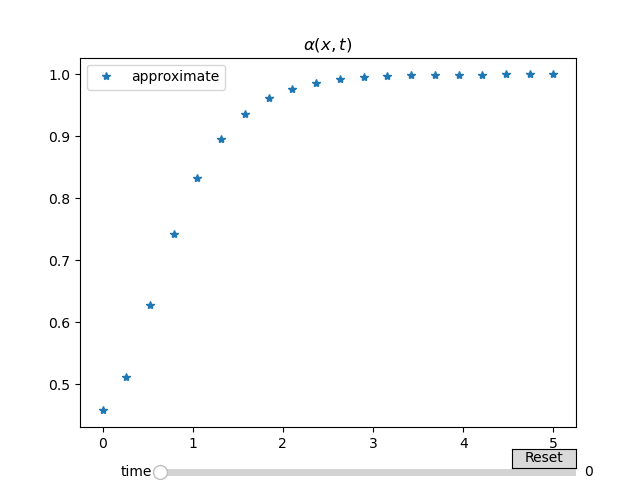

In [111]:
# graph of beta(x) for fixed values of t
plt.close()
fig, axs = plt.subplots(num=' ')
p, = axs.plot(X,betas[0], label="approximate",marker='*',linestyle='none')
axs.set_title(r'$\alpha(x,t)$')
plt.legend()

ax_time = fig.add_axes((0.25, 0.001, 0.65, 0.03))

time_slider = Slider(
    ax=ax_time,
    label="time",
    valinit=0,
    valmin =0,
    valmax=num_tsamples,
    valstep=range(num_tsamples),
    orientation="horizontal"
)


# The function to be called anytime a slider's value changes
def update(val):
    p.set_ydata(betas[:][time_slider.val])
    fig.canvas.draw_idle()


# register the update function with each slider
time_slider.on_changed(update)

# Create a `matplotlib.widgets.Button` to reset the sliders to initial values.
time_reset = fig.add_axes((0.8, 0.025, 0.1, 0.04))
button = Button(time_reset, 'Reset', hovercolor='0.975')


def reset(event):
    time_slider.reset()
button.on_clicked(reset)